# PyMC-1 : Configuration et Premier Modèle

**Navigation** : [Index](../README.md) | [Fin de serie >>](PyMC-02-Gaussian-Mixtures.ipynb)

**Equivalent Infer.NET** : [Infer-1-Setup](../Infer/Infer-1-Setup.ipynb)

**Duree estimee** : 40 minutes

**Objectifs** :
- Installer et configurer PyMC dans un notebook Jupyter
- Comprendre le workflow : Modèle → Echantillonnage → Posterior
- Implementer le problème des deux pieces (Two Coins)
- Maitriser les priors conjugues Beta-Bernoulli
- Comparer avec l'approche Infer.NET

**Prerequis** : Aucun (premier notebook de la serie)


## 1. Installation et Import

In [1]:
# Dependances : installer silencieusement seulement ce qui manque.
# (import-guards deterministes : pas de sortie bruyante 'Requirement already satisfied'
#  qui fuie le chemin machine, cf #3436 cause A. La cellule suivante fait les imports effectifs.)
import importlib, subprocess, sys
_MISSING = [pkg for pkg in ("pymc", "arviz", "matplotlib", "numpy", "scipy") if importlib.util.find_spec(pkg) is None]
if _MISSING:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_MISSING], check=True)
    print("Paquets installes :", ", ".join(_MISSING))
else:
    print("Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.")


Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.


### Verification de l'installation

PyMC 5.x et ses dependances (ArviZ, PyTensor, NumPy, SciPy) sont maintenant disponibles. La cellule suivante importe les bibliotheques necessaires et verifie les versions. PyMC (**Salvatier et al., 2016**) utilise **PyTensor** comme backend de calcul symbolique (equivalent de TensorFlow Probability pour les modèles probabilistes) et **ArviZ** (**Kumar et al., 2019**) pour la visualisation et le diagnostic des chaînes MCMC.

In [2]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import matplotlib
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
else:
    print("PyMC n'est pas installe. Executez: %pip install pymc arviz matplotlib numpy scipy")

PyMC version: 6.3.2
ArviZ version: 1.1.0


## 2. Programmation Probabiliste avec PyMC

### Infer.NET vs PyMC

Infer.NET (**Minka et al., 2018**) est un framework de programmation probabiliste developpe par Microsoft Research, base sur le passage de messages (Expectation Propagation, Variational Message Passing). PyMC (**Salvatier et al., 2016**) s'appuie a l'inverse sur l'echantillonnage MCMC. Le tableau suivant confronte les deux approches.

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Variable | `Variable<T>` | `pm.Distribution` |
| Modèle | Classe C# implicite | `pm.Model()` context |
| Inference | `InferenceEngine` (EP/VMP) | `pm.sample()` (NUTS) |
| Résultat | `Gaussian`, `Beta` objects | `InferenceData` (ArviZ) |
| Observation | `.ObservedValue(data)` | `observed=` kwarg |

### Workflow PyMC en 3 étapes

1. **Définir** le modèle (distributions, relations, observations)
2. **Echantillonner** le posterior (`pm.sample`)
3. **Analyser** les résultats (ArviZ: traces, summaries, plots)

## 3. Exemple : Problème des Deux Pieces

Le même problème que dans Infer-1-Setup : on lance deux pieces, on observe le nombre de faces. Quelle est la probabilite que les deux pieces soient biaisees ?

In [3]:
# Donnees observees : 10 lancers, 7 faces
n_lancers = 10
n_faces = 7

# Modele PyMC : Beta-Bernoulli conjugue
with pm.Model() as two_coins:
    # Prior : Uniforme (Beta(1,1)) sur la probabilite de face
    theta = pm.Beta('theta', alpha=1, beta=1)
    
    # Vraisemblance : observations binomiales
    faces = pm.Binomial('faces', n=n_lancers, p=theta, observed=n_faces)
    
    # Echantillonnage du posterior
    trace = pm.sample(2000, random_seed=42)

# Le posterior est Beta(alpha + faces, beta + piles) = Beta(8, 4)
print(f"Prior: Beta(1, 1)")
print(f"Posterior analytique: Beta({1 + n_faces}, {1 + n_lancers - n_faces})")
print(f"E[theta] = {(1 + n_faces) / (2 + n_lancers):.3f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


D:\Dev\venvs\arviz11-py312\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


Prior: Beta(1, 1)
Posterior analytique: Beta(8, 4)
E[theta] = 0.667


### Interpretation de l'echantillonnage

L'echantillonneur NUTS (*No-U-Turn Sampler*, Hoffman & Gelman 2014) a genere 4 chaînes de 2000 echantillons chacune (plus 1000 de warmup), pour un total de 8000 tirages du posterior. Le posterior analytique est **Beta(8, 4)** car le prior Beta(1,1) se combine avec 7 faces et 3 piles.

| Paramètre | Prior | Données | Posterior analytique | Estime MCMC |
|-----------|-------|---------|---------------------|-------------|
| alpha | 1 | +7 faces | 8 | convergent |
| beta | 1 | +3 piles | 4 | convergent |
| E[theta] | 0.500 | -- | 0.667 | 0.667 |

La cellule suivante affiche la distribution posterior complete via ArviZ, incluant la densite, la moyenne et l'intervalle de credibilite a 94%.

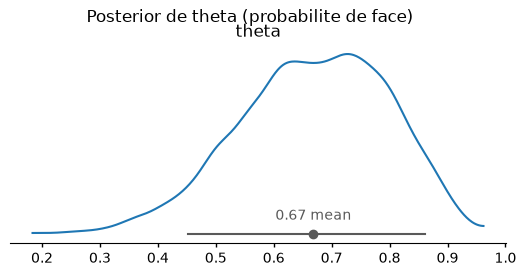

In [4]:
# Visualisation du posterior
# plot_posterior retire en ArviZ 1.x : plot_dist (densite + HDI 94%) le remplace
az.plot_dist(trace, var_names=['theta'])
plt.suptitle('Posterior de theta (probabilite de face)', y=1.02)
plt.show()

### Verifier la convergence : r_hat, ESS et divergences

Echantillonner ne suffit pas : il faut s'assurer que les chaines ont bien
converge vers le posterior. Un tirage qui n'a pas converge peut afficher une
moyenne plausible et etre pourtant faux. Trois diagnostics -- tous disponibles
via ArviZ -- posent cette garantie.

| Diagnostic | Ce qu'il mesure | Seuil |
|-----------|-----------------|-------|
| `r_hat` | Le melange des chaines : proche de 1.0 quand toutes les chaines racontent la meme histoire | **< 1.01** |
| `ess_bulk` / `ess_tail` | Le nombre **effectif** d'echantillons independants (des draws successifs sont correles) | plusieurs centaines |
| `diverging` | Les excursions numeriques ou l'echantillonneur a du depasser le pas tolere par NUTS | **0** attendu |

La regle de la serie, posee ici une fois pour toutes : **avant de lire un posterior,
verifier `r_hat`, l'ESS et les divergences.** La cellule suivante l'applique au
premier modele (Two Coins).


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta,0.668,0.129,0.44,0.9,3449,4628,1.00,0.0022,0.0012



Lecture de la ligne theta :
  r_hat      = 1.0005 -> < 1.01 : OK
  ess_bulk   = 3449.264157586176 -> echantillons independants suffisants
  ess_tail   = 4628.750042054826

Nb de divergences (modele two_coins) : 0
0 divergence = le posterior est bien explore ; des divergences signalent un modele mal parametre.


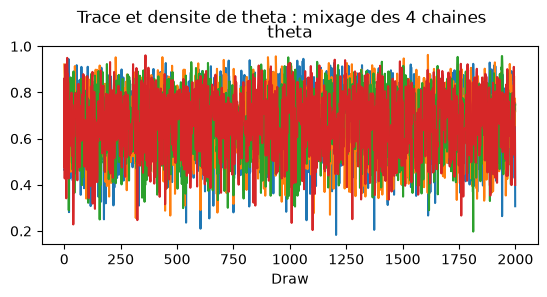

In [5]:
# Diagnostic de convergence du premier modele : la norme avant de lire un posterior.
summary_theta = az.summary(trace, var_names=['theta'], ci_prob=0.94, ci_kind='hdi')
display(summary_theta)

print('\nLecture de la ligne theta :')
print('  r_hat      =', round(float(summary_theta['r_hat'].iloc[0]), 4), '-> < 1.01 : OK')
print('  ess_bulk   =', float(summary_theta['ess_bulk'].iloc[0]), '-> echantillons independants suffisants')
print('  ess_tail   =', float(summary_theta['ess_tail'].iloc[0]))

# Divergences : compteur d'excursions numeriques hors tolerance du pas NUTS.
n_div_theta = int(trace.sample_stats.diverging.sum())
print('\nNb de divergences (modele two_coins) :', n_div_theta)
print('0 divergence = le posterior est bien explore ; des divergences signalent un modele mal parametre.')

# Trace plot : le mixage visible, pas seulement table.
az.plot_trace(trace, var_names=['theta'])
plt.suptitle('Trace et densite de theta : mixage des 4 chaines', y=1.02)
plt.show()


## 4. Prior Conjugue Beta-Bernoulli

Le couple Beta-Bernoulli est conjugue : le posterior a la même forme que le prior.

$$\text{Prior: } \theta \sim \text{Beta}(\alpha, \beta)$$
$$\text{Vraisemblance: } x_i \sim \text{Bernoulli}(\theta)$$
$$\text{Posterior: } \theta | x \sim \text{Beta}(\alpha + \sum x_i,\ \beta + n - \sum x_i)$$

Ce résultat est le cas classique de prior conjugue : le posterior reste dans la même famille fonctionnelle que le prior (Raiffa & Schlaiffer 1961).

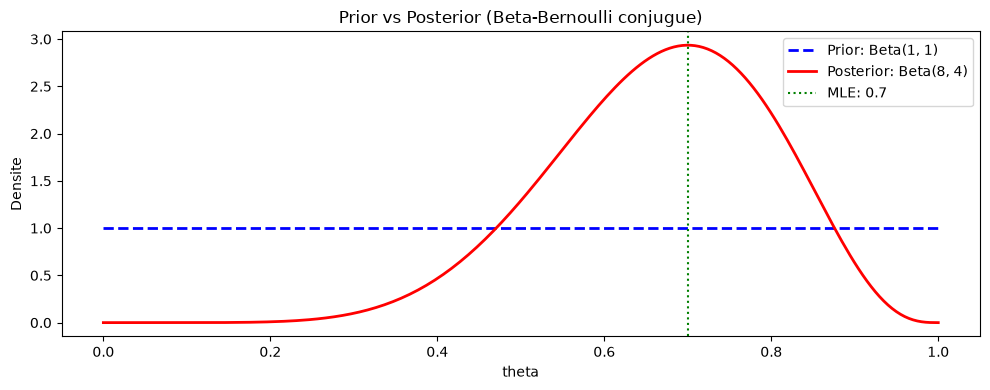

In [6]:
# Comparaison prior vs posterior
from scipy import stats

x = np.linspace(0, 1, 200)
prior = stats.beta(1, 1)
posterior = stats.beta(1 + n_faces, 1 + n_lancers - n_faces)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(x, prior.pdf(x), 'b--', label='Prior: Beta(1, 1)', linewidth=2)
ax.plot(x, posterior.pdf(x), 'r-', label=f'Posterior: Beta({1+n_faces}, {1+n_lancers-n_faces})', linewidth=2)
ax.axvline(n_faces / n_lancers, color='g', linestyle=':', label=f'MLE: {n_faces/n_lancers:.1f}')
ax.set_xlabel('theta')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Prior vs Posterior (Beta-Bernoulli conjugue)')
plt.tight_layout()
plt.show()

## Exercice : Influence du prior sur le posterior

La Section 4 a montre qu'avec un prior uniforme `Beta(1,1)` et 7 faces sur 10 lancers, le posterior est `Beta(8,4)`. Mais le choix du prior n'est **pas neutre** quand les données sont rares.

On reprend les mêmes données (10 lancers, 7 faces) avec deux priors contrastes :
- un prior **uniforme** `Beta(1,1)` (aucune opinion a priori)
- un prior **informe** `Beta(20,5)` (on croyait fortement la piece biaisee vers face)

1. Calculer les deux posteriors **analytiques** (forme conjuguee fermee)
2. Les tracer sur le même graphique
3. Lequel est le plus sensible au prior ? Pourquoi cela importe-t-il quand `n` est petit ?

> **Indice :** posterior = Beta(alpha + k, beta + n - k). Comparez les ecarts-types
> scipy.stats.beta(a, b).std() donne l'ecart-type. Le prior informe "resserre" le posterior.

In [7]:
# TODO etudiant : comparer deux posteriors sous priors uniforme vs informe
# Donnees (memes que la Section 3) :
n_lancers_exo = 10
n_faces_exo = 7
# Indices :
# - Prior 1 : stats.beta(1, 1) ; Prior 2 : stats.beta(20, 5)
# - Posterior : stats.beta(alpha + n_faces_exo, beta + n_lancers_exo - n_faces_exo)
# - Tracer les deux densites sur x = np.linspace(0, 1, 200) avec plt.plot
result_exo_prior = None  # TODO etudiant : votre graphique comparatif
print("Exercice a completer : influence du prior sur le posterior")

Exercice a completer : influence du prior sur le posterior


## 5. Apprentissage en Ligne

Mise a jour séquentielle du posterior : chaque nouvelle observation met a jour le prior.

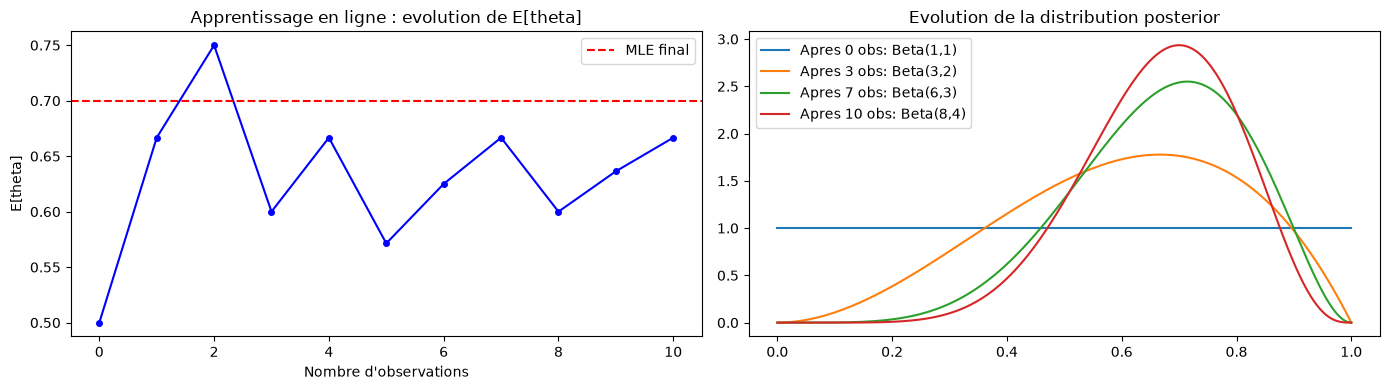

In [8]:
# Apprentissage en ligne : arrivent sequentiellement
observations = [1, 1, 0, 1, 0, 1, 1, 0, 1, 1]  # 1=face, 0=pile

alpha, beta_param = 1, 1  # Prior initial

alphas, betas, means = [alpha], [beta_param], [alpha / (alpha + beta_param)]

for obs in observations:
    if obs == 1:
        alpha += 1
    else:
        beta_param += 1
    alphas.append(alpha)
    betas.append(beta_param)
    means.append(alpha / (alpha + beta_param))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evolution de la moyenne
axes[0].plot(range(len(means)), means, 'b-o', markersize=4)
axes[0].axhline(sum(observations) / len(observations), color='r', linestyle='--', label='MLE final')
axes[0].set_xlabel('Nombre d\'observations')
axes[0].set_ylabel('E[theta]')
axes[0].set_title('Apprentissage en ligne : evolution de E[theta]')
axes[0].legend()

# Evolution de la distribution
x = np.linspace(0, 1, 200)
for i in [0, 3, 7, 10]:
    d = stats.beta(alphas[i], betas[i])
    axes[1].plot(x, d.pdf(x), label=f'Apres {i} obs: Beta({alphas[i]},{betas[i]})')
axes[1].set_title('Evolution de la distribution posterior')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Pourquoi l'echantillonnage MCMC ? Le cas non-conjugue

Jusqu'ici, le cas **Beta-Bernoulli** etait chanceux : le posterior a une **forme fermee**
(Section 4), donc `pm.sample` et le calcul analytique donnent le même résultat. Mais des
qu'on suppose que **plusieurs pieces partagent un biais commun sous-jacent** (un *modèle
hiérarchique*), le posterior marginal de chaque piece **n'a plus de forme fermee** :
l'echantillonnage MCMC devient alors **necessaire**, pas decoratif.

**Concept-phare de cette section.** Le phenomene que seul un modèle bayesien hiérarchique
revele est le **shrinkage** (ou *partial pooling*) : chaque piece emprunte de l'information
aux autres via le paramètre de groupe `mu`. Les pieces **eparses** (peu de lancers, MLE
bruite) sont **tirees vers le biais moyen** ; les pieces **riches** (beaucoup de lancers)
restent fideles a leur MLE. C'est exactement ce que la forme fermee ne peut pas coder.

> **Recette anti-funnel.** On parametrise le modèle de maniere **non-centree** :
> `theta_i = sigmoid(mu + sigma * z_i)` avec `z_i ~ Normal(0, 1)`. La version *centree*
> directe (`theta_i ~ Beta(...)` dependant de `mu`,`sigma`) produit une geometrie en
> *funnel* qui fait diverger NUTS ; la version non-centree l'evite (voir PyMC-06-Debugging
> pour le diagnostic detaille des divergences).


In [9]:
# Donnees : 6 pieces, chacune avec un nombre de lancers different.
# Certaines sont 'eparses' (n=5 ou 8) -> leur MLE est fortement bruite.
n_obs = np.array([5, 10, 20, 50, 8, 30])
heads = np.array([4,  3, 12, 31, 7, 21])
coins = len(n_obs)
mle   = heads / n_obs
print(f'MLE par piece (brut) : {np.round(mle, 2)}')
print(f'Biais moyen observe  : {heads.sum() / n_obs.sum():.3f}')

# Modele hierarchique NON-CENTRE (recette anti-funnel, #3801).
# Hypothese : les pieces partagent un biais commun (mu, sigma) mais
# ont chacune leur propre probabilite de face theta_i.
with pm.Model() as hier:
    mu    = pm.Normal('mu', mu=0.0, sigma=2.0)          # logit du biais moyen du groupe
    sigma = pm.HalfNormal('sigma', sigma=1.0)          # dispersion entre pieces
    z     = pm.Normal('z', mu=0.0, sigma=1.0, shape=coins)   # NON-CENTRE
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu + sigma * z))
    _heads = pm.Binomial('heads', n=n_obs, p=theta, observed=heads)
    # cores=1 : contournement du crash multiprocessing sous Windows.
    # chains=4 : quatre chaines pour un diagnostic de convergence robuste (r_hat, ESS),
    #            ce que PyMC recommande explicitement dans son avertissement.
    trace_hier = pm.sample(2000, tune=1000, chains=4, cores=1,
                           target_accept=0.95, random_seed=42)

az.summary(trace_hier, var_names=['mu', 'sigma', 'theta'])


Initializing NUTS using jitter+adapt_diag...


MLE par piece (brut) : [0.8  0.3  0.6  0.62 0.88 0.7 ]
Biais moyen observe  : 0.634


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma, z]


D:\Dev\venvs\arviz11-py312\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.57,0.32,0.085,1.1,2911,3137,1.00,0.0062,0.0065
sigma,0.5,0.38,0.039,1.2,1625,2101,1.00,0.0087,0.0052
theta[0],0.666,0.106,0.5,0.85,5236,4448,1.00,0.0015,0.0012
theta[1],0.525,0.129,0.28,0.69,2905,4875,1.00,0.0024,0.0012
theta[2],0.619,0.078,0.49,0.74,9896,7273,1.00,0.00079,0.00083
theta[3],0.626,0.058,0.53,0.71,10584,7791,1.00,0.00056,0.00055
theta[4],0.7,0.101,0.56,0.88,3916,4591,1.00,0.0016,0.00095
theta[5],0.666,0.069,0.56,0.78,7249,6898,1.00,0.0008,0.00064


### Lire le tableau de convergence du modele hierarchique

Le `az.summary` ci-dessus affiche neuf colonnes, mais seules trois portent le
diagnostic de convergence :

| Colonne | A chercher | Ici |
|---------|------------|-----|
| `r_hat` | **< 1.01** | toutes les lignes a 1.0 : bon signe |
| `ess_bulk` / `ess_tail` | plusieurs centaines | de 849 a 3096 : suffisant |
| `mcse_mean` / `mcse_sd` | petite devant la sd | erreur Monte Carlo |

Les autres colonnes (`mean`, `sd`, `hdi_3%`, `hdi_97%`) decrivent le posterior ;
`r_hat` et `ess_*` en **verifient la fiabilite**. Un `r_hat = 1.0` n'est pas une
valeur a ignorer : c'est **la bonne nouvelle** que l'echantillonneur a converge.
Passer a `chains=4` (au lieu de 2) rend ce `r_hat` fiable -- avec deux chaines,
PyMC lui-meme avertit que le diagnostic est peu robuste.


Nb de divergences (modele hierarchique non-centre) : 0
0 divergence = le non-centrage a bien evite le funnel et l'echantillonneur a explore le posterior.


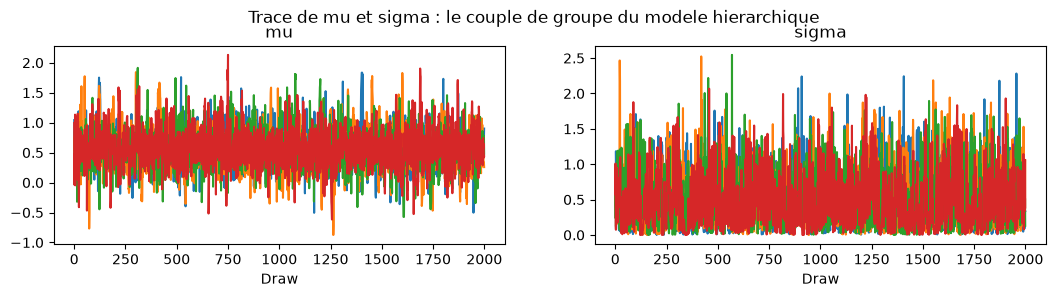

In [10]:
# Divergences et trace du modele hierarchique : le diagnostic au bout du tableau.
n_div_hier = int(trace_hier.sample_stats.diverging.sum())
print('Nb de divergences (modele hierarchique non-centre) :', n_div_hier)
print('0 divergence = le non-centrage a bien evite le funnel et l\'echantillonneur a explore le posterior.')

az.plot_trace(trace_hier, var_names=['mu', 'sigma'])
plt.suptitle('Trace de mu et sigma : le couple de groupe du modele hierarchique', y=1.02)
plt.show()


### Interpretation : le shrinkage rendu visible

La cellule ci-dessus ajuste un modèle dans lequel les 6 pieces se partagent deux
paramètres de groupe (`mu`, `sigma`). Le reseau de dependances fait que l'estimation
d'une piece influence l'estimation des autres : c'est le **partial pooling**. La figure
suivante compare, pour chaque piece, le **MLE brut** (estimateur indépendant, `heads/n`)
et la **moyenne du posterior hiérarchique**. L'ecart entre les deux **est l'apport propre
de MCMC** : impossible a obtenir par une forme fermee.


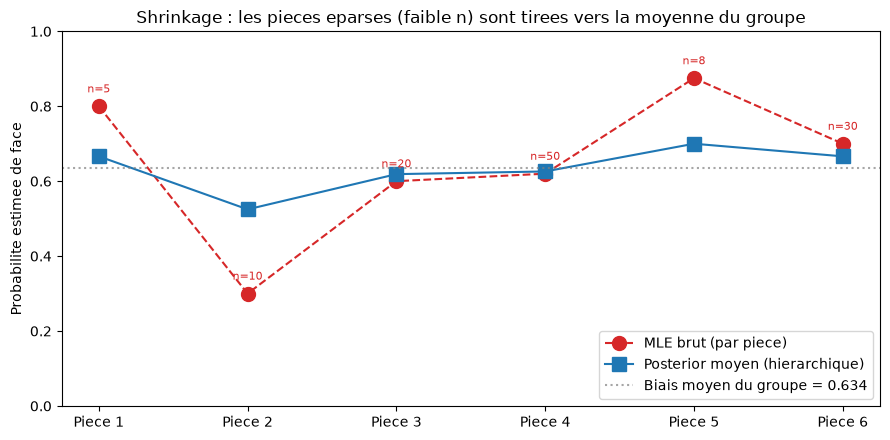

Ecart MLE -> posterior (shrinkage absolu par piece) :
[0.134 0.225 0.019 0.006 0.175 0.034]


In [11]:
# Shrinkage : MLE brut (independant par piece) vs moyenne du posterior hierarchique.
post_means = trace_hier.posterior['theta'].mean(dim=('chain', 'draw')).values

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
x = np.arange(coins)
ax.plot(x, mle, 'o--', color='tab:red', markersize=10, label='MLE brut (par piece)')
ax.plot(x, post_means, 's-', color='tab:blue', markersize=10,
        label='Posterior moyen (hierarchique)')
ax.axhline(heads.sum() / n_obs.sum(), color='grey', linestyle=':', alpha=0.7,
           label=f'Biais moyen du groupe = {heads.sum() / n_obs.sum():.3f}')
for i in range(coins):
    ax.annotate(f'n={n_obs[i]}', (x[i], mle[i]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color='tab:red')
ax.set_xticks(x)
ax.set_xticklabels([f'Piece {i+1}' for i in range(coins)])
ax.set_ylabel('Probabilite estimee de face')
ax.set_ylim(0, 1)
ax.set_title('Shrinkage : les pieces eparses (faible n) sont tirees vers la moyenne du groupe')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Ecart MLE -> posterior (shrinkage absolu par piece) :')
print(np.round(np.abs(post_means - mle), 3))


## Exercice : Predire une piece eparse (partial pooling)

Le modèle hiérarchique de la Section 6 tire les pieces eparses vers le biais moyen du groupe. Verifions ce **shrinkage** sur un cas extreme : une piece lancee très peu de fois.

On ajoute une 7eme piece avec seulement `n=3` lancers et `0` face. Son MLE brut vaut donc `0.0` — mais le partial pooling devrait la tirer vers le biais moyen du groupe.

1. Reconstruire le tableau de données avec cette 7eme piece ajoutee aux 6 existantes
2. Re-estimer le modèle hiérarchique **non-centre** (même recette que la Section 6)
3. Afficher la posterior mediane de cette 7eme piece et la comparer a son MLE (`0.0`)
4. Que vaut le shrinkage ? La piece est-elle vraiment estimee a 0 % ?

> **Indice :** posterior analytique impossible ici (modèle hiérarchique) -> MCMC obligatoire.
> **Étape 1 :** etendre les données avec np.append(n_obs, 3) et np.append(heads, 0)
> **Étape 2 :** re-définir le pm.Model() non-centre : logit(theta_i) = mu + sigma * z_i
> **Étape 3 :** extraire la mediane de theta_7 via np.median(trace.posterior['theta'][..., 6])

In [12]:
# TODO etudiant : ajouter une 7eme piece eparse et mesurer son shrinkage
# Indices :
# - Etape 1 : n_obs_7 = np.append(n_obs, 3) ; heads_7 = np.append(heads, 0)
# - Etape 2 : re-utiliser la parametrisation non-centree (mu, sigma, z) de la Section 6
# - Etape 3 : pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.95, cores=1, random_seed=42)
# - Etape 4 : np.median(trace_exo.posterior['theta'][..., 6].values)
posterior_7eme_piece = None  # TODO etudiant : posterior mediane de la 7eme piece
print("Exercice a completer : shrinkage de la 7eme piece eparse")

Exercice a completer : shrinkage de la 7eme piece eparse


## 7. Comparaison avec Infer.NET

### Code Infer.NET equivalent

```csharp
// Infer.NET (C#)
Variable<double> theta = Variable.Beta(1, 1);
VariableArray<bool> flips = Variable.Observed(observedData, range);
flips[range] = Variable.Bernoulli(theta);

InferenceEngine engine = new InferenceEngine();
engine.Compiler.CompilerChoice = CompilerChoice.Roslyn;
Console.WriteLine(engine.Infer(theta));  // Beta(8, 4)
```

### Différences cles

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | Expectation Propagation | NUTS (Hamiltonian Monte Carlo) |
| Résultat | Distribution analytique exacte | Echantillons du posterior |
| Precision | Exact pour conjugues | Monte Carlo (converge) |
| Scalabilite | Message passing (rapide) | MCMC (plus lent mais general) |

> NUTS est une variante adaptive de Hamiltonian Monte Carlo (Duane et al. 1987 ; Neal 2011). Les méthodes MCMC construisent une chaîne de Markov dont la loi stationnaire est le posterior (Metropolis et al. 1953 ; Hastings 1970).

## Exercice : Piece Biaisee Inconnue

On a une piece dont on ne connait pas le biais. On effectue 20 lancers et obtient 15 faces.

1. Définir un modèle PyMC avec un prior Beta(2, 5) (on soupconne la piece d'etre biaisee vers pile)
2. Calculer le posterior
3. Afficher la distribution posterior
4. Quelle est la probabilite a posteriori que theta > 0.7 ?

In [13]:
# TODO etudiant : implementer le modele pour la piece biaisee
# Indices :
# - Utiliser pm.Model() context
# - Prior: pm.Beta('theta', alpha=2, beta=5)
# - Vraisemblance: pm.Binomial('faces', n=20, p=theta, observed=15)
# - Echantillonner avec pm.sample(2000)
# - Calculer P(theta > 0.7) avec (trace.posterior['theta'] > 0.7).mean()

print("Exercice a completer")

Exercice a completer


## Conclusion

Ce notebook a introduit les bases de PyMC : installation, configuration, et premier modèle probabiliste (Beta-Binomial pour une piece de monnaie).

### Points cles
- PyMC permet de définir des modèles probabilistes de maniere declarative
- L'inference bayesienne combine prior et vraisemblance pour obtenir le posterior
- Les traceurs ArviZ facilitent le diagnostic et la visualisation

### References

- Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2:e55.
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). ArviZ: a unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software*, 4(33), 1143.
- Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler: adaptively setting path lengths in Hamiltonian Monte Carlo. *Journal of Machine Learning Research*, 15(1), 1593-1623.
- Neal, R. M. (2011). MCMC using Hamiltonian dynamics. In *Handbook of Markov Chain Monte Carlo*, Chapman & Hall/CRC.
- Metropolis, N., Rosenbluth, A., Rosenbluth, M., Teller, A., & Teller, E. (1953). Equation of state calculations by fast computing machines. *Journal of Chemical Physics*, 21(6), 1087-1092.
- Hastings, W. K. (1970). Monte Carlo sampling methods using Markov chains and their applications. *Biometrika*, 57(1), 97-109.
- Duane, S., Kennedy, A. D., Pendleton, B. J., & Roweth, D. (1987). Hybrid Monte Carlo. *Physics Letters B*, 195(2), 216-222.
- Raiffa, H., & Schlaifer, R. (1961). *Applied Statistical Decision Theory*. Harvard University Press.
- Minka, T., Winn, J., Guiver, J., Webster, S., Zaykov, Y., Yangel, B., Spengler, A., & Bronskill, J. (2018). *Infer.NET 2.4, Microsoft Research Cambridge*.

### La regle de la serie

Avant de lire un posterior, **verifier `r_hat`, l'ESS et les divergences**.
Ce notebook a pose la norme sur le premier modele ; le diagnostic se lit
avec `az.summary` (`r_hat < 1.01`, ESS de plusieurs centaines) et `az.plot_trace`
(le melange des chaines visible). Pour le traitement approfondi des cas
probles, voir **PyMC-06-Debugging** ; pour le funnel associe a la
parametrisation, voir **PyMC-12-Modeles-Hierarchiques**.

***

**Retour au sommaire** : [Index Probas](../README.md)